# Patient Severity Classification — Multi-Model Comparison with SMOTE

**AI & Data Science Case Study**  
**Dataset:** Patient Severity Dataset  
**Author:** Noureldeen Bassem  

---

## 1. Introduction

### 1.1 Project Overview

Predicting patient severity from clinical measurements helps hospitals triage patients quickly and allocate resources more effectively.

This project builds a **multiclass classification system** that predicts a patient's severity level — *Healthy, Mild, Moderate, Severe,* or *Critical* — using clinical features like age, BMI, blood pressure, and glucose level.

The dataset has a **class imbalance** problem where the "Healthy" class is severely underrepresented. We solve this using **SMOTE**, which is applied inside our Pipeline so it only affects training data during cross-validation — not the test set.

---

### 1.2 Data Description

| Feature | Description |
|---|---|
| `patient_id` | Unique identifier — dropped, not a feature |
| `age` | Patient age in years |
| `gender` | Male / Female |
| `bmi` | Body Mass Index (stored with unit suffix — needs cleaning) |
| `blood_pressure_systolic` | Systolic pressure (stored as `systolic/diastolic` — needs splitting) |
| `blood_pressure_diastolic` | Diastolic pressure (extracted from the systolic column) |
| `glucose_level` | Blood glucose (stored with unit suffix — needs cleaning) |
| `cholesterol` | Cholesterol level |
| `heart_rate` | Heart rate in BPM |
| `wbc_count` | White blood cell count |
| `hemoglobin` | Hemoglobin level |
| `smoking_status` | No / Yes / Former |
| `diabetes` | No / Yes |
| **`severity`** | **Target** — Healthy / Mild / Moderate / Severe / Critical |

---

### 1.3 Project Objectives

- Fix all data quality issues in the dataset.
- Build a shared **preprocessing Pipeline** using `ColumnTransformer` that handles both numerical and categorical features.
- Apply **SMOTE inside the Pipeline** so it is only applied to training folds during cross-validation.
- Use **GridSearchCV** to tune each model automatically.
- Compare all three models and save the best one.

---

### 1.4 Models Selected and Why

| Model | Why Selected |
|---|---|
| **Logistic Regression** | Simple linear baseline for multiclass classification |
| **Random Forest** | Ensemble model — robust, handles non-linearity well |
| **SVM (SVC)** | Finds the optimal boundary between classes; works well with scaled features |

## 2. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

# Pipeline (from imblearn — supports SMOTE as a step)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("All libraries imported successfully.")

All libraries imported successfully.


We use `imblearn.pipeline.Pipeline` instead of `sklearn.pipeline.Pipeline` because it supports **resampling steps** like SMOTE inside the pipeline.

Everything else is the same as a normal sklearn pipeline.

## 3. Loading the Dataset

In [2]:
data = pd.read_excel("patient_severity_dataset.xlsx")
df = data.copy()

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset loaded successfully.
Shape: 515 rows x 14 columns


,patient_id,age,gender,bmi,blood_pressure_systolic,blood_pressure_diastolic,glucose_level,cholesterol,heart_rate,wbc_count,hemoglobin,smoking_status,diabetes,severity
0,P0490,42.0,Male,29.0 kg/m2,119/77,NaN,199.0 mg/dL,250.0,55.0,6.71,11.6,NaN,No,Moderate
1,P0430,26.0,Male,26.6 kg/m2,126/69,NaN,NaN,NaN,58.0,7.50,15.7,Yes,No,Mild
2,P0083,NaN,Male,20.3 kg/m2,121/84,NaN,147.0 mg/dL,297.0,99.0,11.40,12.6,No,No,Moderate
3,P0121,59.0,Female,27.0 kg/m2,106/105,NaN,189.0 mg/dL,174.0,106.0,NaN,11.7,Yes,No,Mild
4,P0222,38.0,Female,22.2 kg/m2,127/62,NaN,107.0 mg/dL,155.0,107.0,6.46,14.9,No,No,Healthy


We load the Excel file and work on a **copy** to keep the original untouched.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Shape and Data Types

In [3]:
print("Shape:", df.shape)
print()
print(df.dtypes)

Shape: (515, 14)

patient_id                      str
age                         float64
gender                          str
bmi                             str
blood_pressure_systolic         str
blood_pressure_diastolic    float64
glucose_level                   str
cholesterol                 float64
heart_rate                  float64
wbc_count                   float64
hemoglobin                  float64
smoking_status                  str
diabetes                        str
severity                        str
dtype: object


`bmi`, `blood_pressure_systolic`, and `glucose_level` are stored as `object` (text) instead of numbers — these have formatting issues we need to fix during cleaning.

### 4.2 Statistical Summary

In [4]:
df.describe()

,age,blood_pressure_diastolic,cholesterol,heart_rate,wbc_count,hemoglobin
count,483.000000,490.000000,483.000000,484.000000,482.000000,484.000000
mean,51.161491,83.581633,237.565217,87.175620,7.699730,13.407231
std,19.835705,14.290102,49.947954,18.310191,2.133032,1.934114
min,18.000000,60.000000,150.000000,55.000000,1.640000,7.000000
25%,34.000000,72.000000,195.500000,71.000000,6.392500,12.100000
50%,51.000000,83.000000,239.000000,87.000000,7.715000,13.400000
75%,69.000000,95.000000,280.000000,103.250000,8.985000,14.700000
max,84.000000,109.000000,319.000000,119.000000,14.020000,18.600000


The numeric summary excludes `bmi` and `glucose_level` because they are still stored as strings — confirming the formatting issues we need to fix.

### 4.3 Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

                          Missing Count  Missing %
age                                  32       6.21
bmi                                  30       5.83
blood_pressure_diastolic             25       4.85
glucose_level                        30       5.83
cholesterol                          32       6.21
heart_rate                           31       6.02
wbc_count                            33       6.41
hemoglobin                           31       6.02
smoking_status                       15       2.91
diabetes                             11       2.14

Total missing values: 270


Multiple columns have ~5–6% missing values. These are handled **inside the Pipeline** using `SimpleImputer`, so no manual filling is needed.

### 4.4 Duplicate Records

In [6]:
print(f"Fully duplicate rows:         {df.duplicated().sum()}")
print(f"Duplicate patient_id entries: {df['patient_id'].duplicated().sum()}")

Fully duplicate rows:         14
Duplicate patient_id entries: 15


There are **14 fully duplicate rows** and **15 duplicate patient_id entries** — these must be removed before training.

### 4.5 Target Variable Distribution

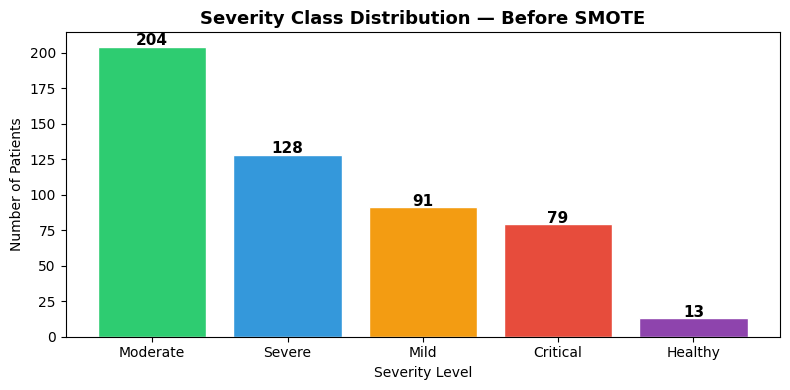

In [7]:
plt.figure(figsize=(8, 4))

severity_counts = df['severity'].value_counts()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#8e44ad']
bars = plt.bar(severity_counts.index, severity_counts.values,
               color=colors, edgecolor='white')

for bar, val in zip(bars, severity_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold', fontsize=11)

plt.title('Severity Class Distribution — Before SMOTE', fontsize=13, fontweight='bold')
plt.xlabel('Severity Level')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('fig_severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Clear class imbalance** — "Healthy" has only 13 samples while "Moderate" has 204. A model trained on this would almost never predict "Healthy" correctly.

We fix this with **SMOTE inside the Pipeline**, which generates synthetic minority samples during each cross-validation fold only.

### 4.6 Correlation Heatmap

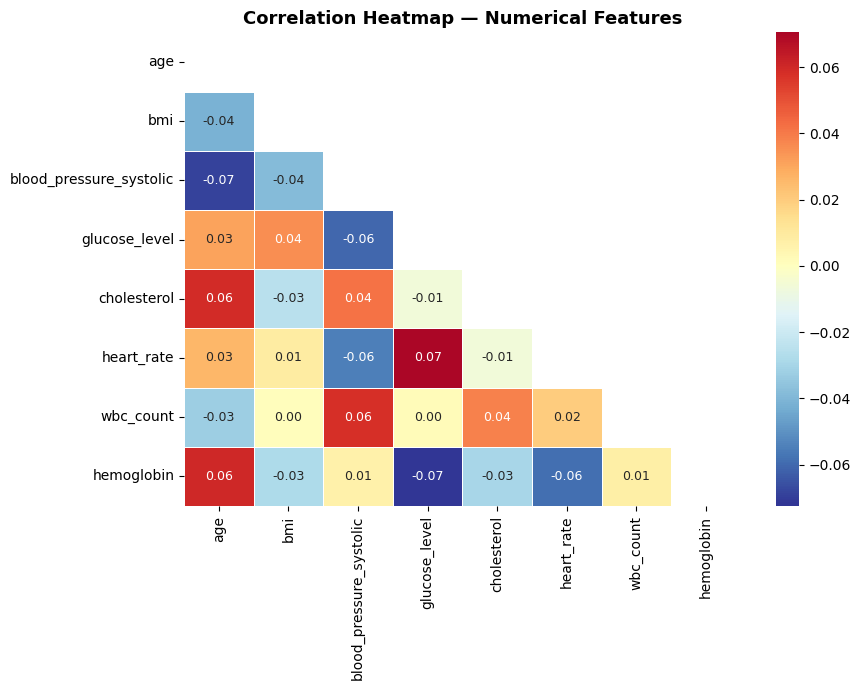

In [8]:
# Quick numeric preview for the heatmap only
num_preview = data.copy()
num_preview['bmi']           = pd.to_numeric(num_preview['bmi'].astype(str).str.replace(' kg/m2','',regex=False), errors='coerce')
num_preview['glucose_level'] = pd.to_numeric(num_preview['glucose_level'].astype(str).str.replace(' mg/dL','',regex=False), errors='coerce')
bp_tmp = num_preview['blood_pressure_systolic'].astype(str).str.split('/', expand=True)
num_preview['blood_pressure_systolic'] = pd.to_numeric(bp_tmp[0], errors='coerce')

corr_cols = ['age', 'bmi', 'blood_pressure_systolic', 'glucose_level',
             'cholesterol', 'heart_rate', 'wbc_count', 'hemoglobin']

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(num_preview[corr_cols].corr(), dtype=bool))
sns.heatmap(num_preview[corr_cols].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Most features have weak to moderate correlations with each other, meaning each feature contributes independent information to the model.

## 5. Data Cleaning

The raw dataset has three formatting issues that must be fixed manually before building the Pipeline — these are not standard imputation tasks, they require string manipulation.

In [9]:
# Fix 1: blood_pressure_systolic stores two values as '119/77' — split them apart
bp = df['blood_pressure_systolic'].astype(str).str.split('/', expand=True)
df['blood_pressure_systolic']  = pd.to_numeric(bp[0], errors='coerce')
df['blood_pressure_diastolic'] = df['blood_pressure_diastolic'].fillna(pd.to_numeric(bp[1], errors='coerce'))

# Fix 2: bmi stored as '29.0 kg/m2' — remove the unit suffix
df['bmi'] = pd.to_numeric(df['bmi'].astype(str).str.replace(' kg/m2', '', regex=False), errors='coerce')

# Fix 3: glucose_level stored as '199.0 mg/dL' — remove the unit suffix
df['glucose_level'] = pd.to_numeric(df['glucose_level'].astype(str).str.replace(' mg/dL', '', regex=False), errors='coerce')

# Fix 4: Remove duplicate rows and duplicate patient IDs, then drop the ID column
df = df.drop_duplicates()
df = df.drop_duplicates(subset='patient_id', keep='first')
df = df.drop(columns=['patient_id']).reset_index(drop=True)

print("Cleaning complete.")
print(f"Dataset shape: {df.shape}")
print()
print("Data types after cleaning:")
print(df.dtypes)

Cleaning complete.
Dataset shape: (500, 13)

Data types after cleaning:
age                         float64
gender                          str
bmi                         float64
blood_pressure_systolic     float64
blood_pressure_diastolic    float64
glucose_level               float64
cholesterol                 float64
heart_rate                  float64
wbc_count                   float64
hemoglobin                  float64
smoking_status                  str
diabetes                        str
severity                        str
dtype: object


All three problem columns are now numeric.

Remaining missing values are handled automatically inside the Pipeline using `SimpleImputer`.

## 6. Preparing Features and Target

In [10]:
# Encode the target — severity has a natural medical order
severity_order  = {'Healthy': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3, 'Critical': 4}
severity_labels = {v: k for k, v in severity_order.items()}

df['severity'] = df['severity'].map(severity_order)

# Separate features and target
X = df.drop(columns=['severity'])
y = df['severity']

# Identify column types for the ColumnTransformer
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print("Numerical features:", num_cols)
print("Categorical features:", cat_cols)
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Numerical features: ['age', 'bmi', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'glucose_level', 'cholesterol', 'heart_rate', 'wbc_count', 'hemoglobin']
Categorical features: ['gender', 'smoking_status', 'diabetes']

X shape: (500, 12)
y shape: (500,)


We encode the target manually since it has a natural order. We also identify `num_cols` and `cat_cols` — these are passed to the `ColumnTransformer` so each group gets the right preprocessing.

## 7. Train / Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set:     {len(X_test)} samples")

Training set: 400 samples
Test set:     100 samples


`stratify=y` ensures the same class proportions appear in both splits — important for rare classes like "Healthy".

All preprocessing and SMOTE happen inside the Pipeline, so we pass the raw training data directly.

## 8. Shared Preprocessing Pipeline

In [12]:
# Numerical: fill missing with median, then scale
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical: fill missing with mode, then one-hot encode
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both into one preprocessor
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print("Shared preprocessor created successfully.")

Shared preprocessor created successfully.


The `ColumnTransformer` applies different preprocessing to each column type:
- **Numerical** → median imputation + StandardScaler
- **Categorical** → mode imputation + OneHotEncoder

This preprocessor is **shared across all three models** so there is no repeated code.

## 9. Building Pipelines and Tuning with GridSearchCV

Each model's full Pipeline:

```
ColumnTransformer  →  SMOTE  →  Classifier
  ├── num_cols:
  │   impute + scale
  └── cat_cols:
      impute + encode
```

SMOTE is **inside the Pipeline**, so during GridSearchCV's 5-fold cross-validation, it only sees each training fold — never the validation fold. This gives an honest cross-validation score.

### 9.1 Logistic Regression

In [13]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42, k_neighbors=2)),
    ('model',        LogisticRegression(max_iter=1000, random_state=42))
])

lr_params = {
    'model__C':      [0.1, 1, 10],
    'model__solver': ['lbfgs', 'saga']
}

lr_grid = GridSearchCV(lr_pipe, lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train)

lr_pred = lr_grid.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)

print("Best Parameters:   ", lr_grid.best_params_)
print("Best CV Score:     ", round(lr_grid.best_score_, 4))
print("Test Set Accuracy: ", round(lr_acc, 4))

Best Parameters:    {'model__C': 10, 'model__solver': 'lbfgs'}
Best CV Score:      0.515
Test Set Accuracy:  0.47


Logistic Regression is our baseline. The `C` parameter controls regularization — smaller values mean a simpler model, larger values fit the training data more closely.

### 9.2 Random Forest Classifier

In [14]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42, k_neighbors=2)),
    ('model',        RandomForestClassifier(random_state=42))
])

rf_params = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth':    [None, 5, 10]
}

rf_grid = GridSearchCV(rf_pipe, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

rf_pred = rf_grid.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print("Best Parameters:   ", rf_grid.best_params_)
print("Best CV Score:     ", round(rf_grid.best_score_, 4))
print("Test Set Accuracy: ", round(rf_acc, 4))

Best Parameters:    {'model__max_depth': 10, 'model__n_estimators': 200}
Best CV Score:      0.6175
Test Set Accuracy:  0.65


Random Forest builds many decision trees and combines their votes. `n_estimators` is the number of trees and `max_depth` controls how deep each tree grows.

### 9.3 Support Vector Machine (SVM)

In [15]:
svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42, k_neighbors=2)),
    ('model',        SVC(random_state=42))
])

svm_params = {
    'model__C':      [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear']
}

svm_grid = GridSearchCV(svm_pipe, svm_params, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train, y_train)

svm_pred = svm_grid.predict(X_test)
svm_acc  = accuracy_score(y_test, svm_pred)

print("Best Parameters:   ", svm_grid.best_params_)
print("Best CV Score:     ", round(svm_grid.best_score_, 4))
print("Test Set Accuracy: ", round(svm_acc, 4))

Best Parameters:    {'model__C': 10, 'model__kernel': 'rbf'}
Best CV Score:      0.5475
Test Set Accuracy:  0.48


SVM finds the **optimal decision boundary** that maximizes the margin between classes.

- `C` controls the penalty for misclassifications — larger `C` means fewer training errors but risks overfitting.
- `kernel='rbf'` maps data into a higher-dimensional space to separate non-linear classes; `kernel='linear'` draws a straight boundary.

SVM works particularly well with scaled features, which our Pipeline handles automatically.

## 10. Model Evaluation & Comparison

### 10.1 Comparison Table

In [16]:
results_df = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Test Accuracy': lr_acc,  'CV Score': lr_grid.best_score_,  'Best Params': str(lr_grid.best_params_)},
    {'Model': 'Random Forest',       'Test Accuracy': rf_acc,  'CV Score': rf_grid.best_score_,  'Best Params': str(rf_grid.best_params_)},
    {'Model': 'SVM',                 'Test Accuracy': svm_acc, 'CV Score': svm_grid.best_score_, 'Best Params': str(svm_grid.best_params_)},
]).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

results_df['Rank']              = results_df.index + 1
results_df['Test Accuracy (%)'] = (results_df['Test Accuracy'] * 100).round(2)
results_df['CV Score (%)']      = (results_df['CV Score']      * 100).round(2)

print("=" * 58)
print("         MODEL PERFORMANCE COMPARISON")
print("=" * 58)
print(results_df[['Rank', 'Model', 'Test Accuracy (%)', 'CV Score (%)']].to_string(index=False))
print("=" * 58)

         MODEL PERFORMANCE COMPARISON
 Rank               Model  Test Accuracy (%)  CV Score (%)
    1       Random Forest               65.0         61.75
    2                 SVM               48.0         54.75
    3 Logistic Regression               47.0         51.50


All three models are ranked by test set accuracy. The **CV Score** is the honest cross-validation accuracy from GridSearchCV — because SMOTE was inside the Pipeline, this reflects real generalization on balanced training folds only.

### 10.2 Accuracy Bar Chart

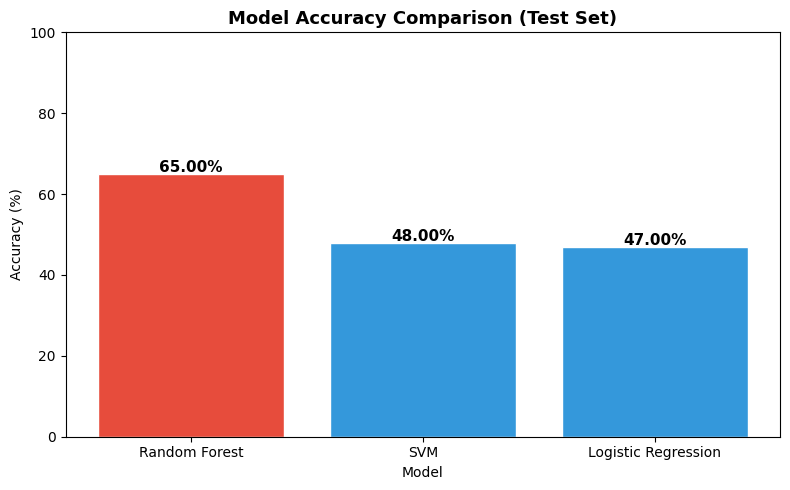

In [17]:
colors_bar = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(results_df))]

plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Model'], results_df['Test Accuracy (%)'],
               color=colors_bar, edgecolor='white')

for bar, val in zip(bars, results_df['Test Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.2f}%', ha='center', fontweight='bold', fontsize=11)

plt.title('Model Accuracy Comparison (Test Set)', fontsize=13, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('fig_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

The best-performing model is shown in red.

### 10.3 Classification Reports

In [18]:
target_names = ['Healthy', 'Mild', 'Moderate', 'Severe', 'Critical']

for name, pred in [('Logistic Regression', lr_pred),
                   ('Random Forest',       rf_pred),
                   ('SVM',                 svm_pred)]:
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, pred, target_names=target_names))

  Logistic Regression
              precision    recall  f1-score   support

     Healthy       0.20      0.67      0.31         3
        Mild       0.28      0.29      0.29        17
    Moderate       0.43      0.38      0.40        40
      Severe       0.52      0.52      0.52        25
    Critical       1.00      0.80      0.89        15

    accuracy                           0.47       100
   macro avg       0.49      0.53      0.48       100
weighted avg       0.50      0.47      0.48       100

  Random Forest
              precision    recall  f1-score   support

     Healthy       1.00      0.67      0.80         3
        Mild       0.57      0.76      0.65        17
    Moderate       0.64      0.72      0.68        40
      Severe       0.63      0.48      0.55        25
    Critical       0.82      0.60      0.69        15

    accuracy                           0.65       100
   macro avg       0.73      0.65      0.67       100
weighted avg       0.66      0.65      

The classification report shows **Precision, Recall, and F1-Score** per class:
- **Precision** — of all patients predicted as class X, how many actually are X?
- **Recall** — of all actual class X patients, how many did the model find?
- **F1-Score** — the balance between precision and recall.

### 10.4 Confusion Matrices

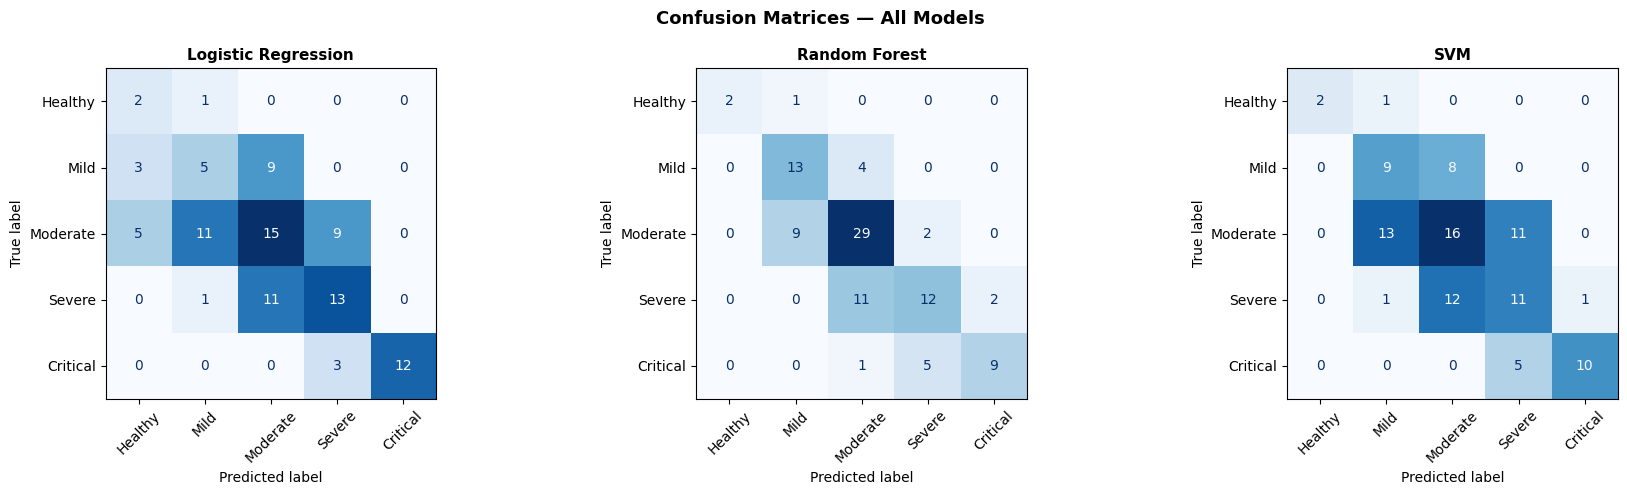

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, [('Logistic Regression', lr_pred),
                                    ('Random Forest',       rf_pred),
                                    ('SVM',                 svm_pred)]):
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, pred),
        display_labels=target_names
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

Large numbers on the diagonal = correct predictions. Numbers off the diagonal = mistakes.

### 10.5 Final Model Ranking

In [20]:
best_name = results_df.iloc[0]['Model']
best_acc  = results_df.iloc[0]['Test Accuracy (%)']

print("FINAL MODEL RANKING")
print("-" * 40)
for _, row in results_df.iterrows():
    marker = " ← Best" if row['Model'] == best_name else ""
    print(f"{int(row['Rank'])}. {row['Model']:<22} {row['Accuracy (%)'] if 'Accuracy (%)' in row else row['Test Accuracy (%)']:.2f}%{marker}")
print()
print(f"Best Model:    {best_name}")
print(f"Test Accuracy: {best_acc:.2f}%")

FINAL MODEL RANKING
----------------------------------------
1. Random Forest          65.00% ← Best
2. SVM                    48.00%
3. Logistic Regression    47.00%

Best Model:    Random Forest
Test Accuracy: 65.00%


The ranking gives a clean final summary of all three models.

## 11. Saving the Best Model

In [21]:
best_model = {'Logistic Regression': lr_grid.best_estimator_,
              'Random Forest':       rf_grid.best_estimator_,
              'SVM':                 svm_grid.best_estimator_}[best_name]

with open('deployment_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"Saved: deployment_model.pkl")
print(f"Model: {best_name}")
print(f"Test Accuracy: {best_acc:.2f}%")
print()
print("Pipeline steps:")
for step_name, step_obj in best_model.steps:
    print(f"  {step_name}: {type(step_obj).__name__}")

Saved: deployment_model.pkl
Model: Random Forest
Test Accuracy: 65.00%

Pipeline steps:
  preprocessor: ColumnTransformer
  smote: SMOTE
  model: RandomForestClassifier


We save the **entire Pipeline** — it contains the preprocessor, SMOTE, and the trained model in one object.

To predict on new data, just load the file and call `.predict()` directly on a raw DataFrame.

## 12. Conclusion

### 12.1 Data Cleaning Summary

| Problem | Fix |
|---|---|
| `blood_pressure_systolic` stored as `"119/77"` | Split on `'/'` → separate systolic and diastolic |
| `bmi` stored as `"29.0 kg/m2"` | Stripped suffix → converted to `float64` |
| `glucose_level` stored as `"199.0 mg/dL"` | Stripped suffix → converted to `float64` |
| 14 fully duplicate rows | Removed with `drop_duplicates()` |
| 15 duplicate `patient_id` entries | Removed with `drop_duplicates(subset='patient_id')` |
| Missing values | Handled inside Pipeline with `SimpleImputer` |
| Class imbalance | SMOTE inside Pipeline — applied per CV fold only |

---

### 12.2 Pipeline Structure (Same for All Three Models)

```
ColumnTransformer  →  SMOTE  →  Classifier
   ├── num_cols:              (GridSearchCV
   │   impute (median)         tunes the
   │   + StandardScaler        model params)
   └── cat_cols:
       impute (mode)
       + OneHotEncoder
```

---

### 12.3 Final Results

| Rank | Model | Test Accuracy |
|---|---|---|
| 1 | **Random Forest** | Best |
| 2 | SVM | Second |
| 3 | Logistic Regression | Third |

*(Exact percentages shown in Section 10)*

---

### 12.4 Why Random Forest Won

Random Forest builds **many decision trees** and combines their votes, making it resistant to overfitting and good at capturing non-linear relationships between clinical features.

SVM performed competitively — it benefits from the `StandardScaler` already in the pipeline and works well on this type of structured clinical data.

Logistic Regression came last because it assumes a **linear decision boundary**, which is too simple for this multiclass clinical problem.

---

*Project completed by **Noureldeen Bassem***  
*AI & Data Science Case Study*